<a href="https://colab.research.google.com/github/gruben123/GenAI/blob/main/RAG_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **TEXT-to-SQL Workflow**

#Imports

In [1]:
!pip install chromadb -q
!pip install langchain_openai -q
!pip install langchain_chroma -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 1.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently tak

In [2]:
%pwd

'/content'

In [3]:

from typing import Dict, Any
from pydantic import BaseModel, Field
from dataclasses import dataclass
from langgraph.graph import StateGraph, END, START

from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, AIMessage  #HumanMessage, SystemMessage and AIMessage basically all chat-aligned LLM messages and Langchain will change it based on LLM brand
from langgraph.graph.message import add_messages
from typing import List, Annotated

import os
import chromadb
from chromadb.config import Settings
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document

import json
import sys

sys.path.insert(0, '/content/utilities')
from utils import describe_database

import sqlite3

# *Step 1 Ingest Evidence into a Vector Database*

In [4]:
#initialize embeddings(override if already exists)
#embeddings=OpenAIEmbeddings(model="text-embedding-3-small")

#initialize ChromaDB(override if already exists)
chroma_client=chromadb.PersistentClient(path="./chromadb", settings=Settings(anonymized_telemetry=False))

try:
  chroma_client.delete_collection("documents")
except:
  pass

vector_store = Chroma(
    client=chroma_client,
    collection_name="documents",  #name of the database
    #embedding_function=embeddings,
    collection_metadata={"hnsw:space": "cosine"},
)

In [5]:
#this cell is for my own testing of chroma.  Chroma creates a permanent file store where you can see your data.  The file store gets created when you do a pip install

documents=[
    Document(page_content="Langchain make it easier", metadata={"source": "tech"}),
    Document(page_content="chroma is open source and available to everyone", metadata={"source": "tech"}),
    Document(page_content="chroma is good", metadata={"source": "tech"}),
]

ids=["doc_001", "doc_002", "doc_003"]

vector_store.add_documents(documents=documents, ids=ids)

query="what is chroma"
results=vector_store.similarity_search(query, k=2)
print(f"thre results ae {results[0].page_content}")

#or if I want my two result as I ask for k=2
for result in results:
  print(result.page_content)

/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:04<00:00, 20.7MiB/s]


thre results ae chroma is good
chroma is good
chroma is open source and available to everyone


In [6]:
with open('/content/sample_data/dev.json', 'r') as f:
  dev_data=json.load(f)

dev_data[0]
#Evidence is essentially the tribal knowledge something that the LLM may not know and eliminate the reasoning for the llm as someone has done it for us
#'evidence': 'Eligible free rate for K-12 = `Free Meal Count (K-12)` / `Enrollment (K-12)`'  ==> means the free rate for K-12 is the Free Meal Count(k-12) divided by Enrollments(K-12)
#the SQL is a way to get the information for the question for the eligible free rate for K-12 students


{'question_id': 0,
 'db_id': 'california_schools',
 'question': 'What is the highest eligible free rate for K-12 students in the schools in Alameda County?',
 'evidence': 'Eligible free rate for K-12 = `Free Meal Count (K-12)` / `Enrollment (K-12)`',
 'SQL': "SELECT `Free Meal Count (K-12)` / `Enrollment (K-12)` FROM frpm WHERE `County Name` = 'Alameda' ORDER BY (CAST(`Free Meal Count (K-12)` AS REAL) / `Enrollment (K-12)`) DESC LIMIT 1",
 'difficulty': 'simple'}

In [7]:
#Find and print first toxicology question in dev_data
for item in dev_data:
  question=item.get("question","")

  if "toxicology" in question.lower():
    print(item)
    break

{'question_id': 220, 'db_id': 'toxicology', 'question': 'Please list top three elements of the toxicology of the molecule TR000 in alphabetical order.', 'evidence': 'TR000 is the molecule id;', 'SQL': "SELECT DISTINCT T.element FROM atom AS T WHERE T.molecule_id = 'TR000' ORDER BY T.element LIMIT 3", 'difficulty': 'challenging'}


In [8]:
#Find first and print formula 1 question in dev_data --> this one has more than one piece of evidence to use
for item in dev_data:
  question=item.get("question", "")

  if "formula_1" in question.lower() and item.get("evidence", ""):
    print(f"Question: {question}")
    print(f"Evidence: {item.get('evidence', '')}")
    print()

Question: Please give more information about the Formula_1 races that used the Silverstone Circuit.
Evidence: more information refers to url

Question: In which Formula_1 race did Lewis Hamilton rank the highest?
Evidence: rank the highest refers to min(rank); Lewis Hamilton refers to the full name of the driver; Full name of the driver refers to drivers.forename and drivers.surname;

Question: Among the drivers that finished the race in the 2008 Chinese Grand Prix, how many of them have participated in Formula_1 races?
Evidence: COUNT(raceID) > 0 reveals that this driver participated in races; drivers who finished the race refers to time has value.

Question: What is the average fastest lap time in seconds for Lewis Hamilton in all the Formula_1 races?
Evidence: average fastest lap time = avg(fastestLapTime); The time is recorded on 'MM:SS.mmm'

Question: What is the lap record set by Lewis Hamilton in a Formula_1 race?
Evidence: lap recod means the fastest time recorded which refers 

In [9]:
# Create documents from the text-to-SQL examples
documents=[]

for item in dev_data:
  # Create a comprehensive document with question, evidence, and SQL
  evidences=[e.strip() for e in item["evidence"].split(";") if e.strip()]  #if e.strip() means inclduing the stripped string in the new list if is not empty after stripping

  for evidence in evidences:
    doc=Document(
        page_content=evidence,
        metadata={"db_id":item["db_id"]}
    )
    documents.append(doc)

#add the documents to the vector store
print(f"Loading {len(documents)} text-to-sql examples into the vector store")
vector_store.add_documents(documents=documents)
print(f"Added {len(documents)} text-to-sql examples into the vector store")

#show some stats
db_counts={}

for item in dev_data:
  db_id=item["db_id"]
  db_counts[db_id]=db_counts.get(db_id, 0)+1

print(f"\n📊 Database distribution:")

for db_id, count in sorted(db_counts.items()):
  print(f"  - {db_id}: {count} examples")

Loading 2680 text-to-sql examples into the vector store
Added 2680 text-to-sql examples into the vector store

📊 Database distribution:
  - california_schools: 89 examples
  - card_games: 191 examples
  - codebase_community: 186 examples
  - debit_card_specializing: 64 examples
  - european_football_2: 129 examples
  - financial: 106 examples
  - formula_1: 174 examples
  - student_club: 158 examples
  - superhero: 129 examples
  - thrombosis_prediction: 163 examples
  - toxicology: 145 examples


In [10]:
#Test a simple query against the ChromaDB vector store, but only for formula_1 db_id which happens to be the database name as well
test_query="Youngest driver in the 2024 season?"

print(f"\n  Testing Chromadb similarity search for query: '{test_query}' (db_id='formula_1')")

try:
  #Only search for documents with db_id of formula_1
  results=vector_store.similarity_search_with_score(
      test_query,
      k=3,
      filter={"db_id":"formula_1"}
  )

  for i, (doc, score) in enumerate(results):
    print(f"{i}. Score {1-score:.4f} | Content: {doc.page_content[:100]}")  #ChromaDB measure dissimilarity and hence need to do 1-score

  if not results:
    print("No results found")
except Exception as e:
  print(f"Error querying Chromadb: {e}")


  Testing Chromadb similarity search for query: 'Youngest driver in the 2024 season?' (db_id='formula_1')
0. Score 0.7000 | Content: the youngest is a driver where MAX(dob)
1. Score 0.6865 | Content: youngest driver refers to Max (year(dob))
2. Score 0.5953 | Content: Youngest racer = MAX(dob)


In [11]:
#describe database
#test with formula_1

db_path = "/content/chromadb/formula_1.sqlite"
print(describe_database(db_path))

# Build the RAG Workflow

In [12]:
@dataclass
class RetrievedDocument:
  """Represents a document from the vector store"""
  content: str #The main context/text of the document similar when testing the youngest driver in the 2024 season, chroma returns score and page content
  metadata: Dict[str, Any] #metadata associated with the document (chunk, source, etc.)
  score: float #similarity score which is really the 1-score

class RAGState(BaseModel):  #this is essentially the running memory of the workflow.  These are variables we can set while we are moving through the workflow
  """State of the RAG Workflow"""
  db_path: str="" #the path to the db
  sql_result: Dict[str, Any]=Field(default_factory=dict)  #default_factory safely assigns default values
  model_name: str = "gpt-4.1-mini" #the model for the llm
  messages: Annotated[List[BaseMessage], add_messages] = Field(default_factory=list) #BaseMessage defines the data type of AI, human or system message...and this is a conversation history...Annotated will just add to the list of messages
  query: str= "" #user's query
  sql_query:str="" #The SQL generated by the LLM
  reasoning: str="" # the reasoning for the sql query
  retrieved_documents: List[RetrievedDocument]=Field(default_factory=list) #list of retrieved documents
  context: str="" #The combined context from the retrieved result
  final_answer: str="" #final answer generated by the system
  k: int=5 #number of documents to retrieve
  db_id: str="" #The database id

In [13]:
def begin_conversation(state: RAGState)->Dict[str, Any]:  #what ever is returned it must match values from RAGState as it will update it within the workflow
  #create prompt template
  system_prompt="""
    You are a helpful AI Assistant that generates SQL queries to answer user's questions.
    """

  return {
      "messages":[         #messages matches the messages in RAGState...i.e., the Dict[str, Any] is the change to the RAGState
          SystemMessage(content=system_prompt)
      ]
  }

In [14]:
def process_query(state: RAGState)->Dict[str, Any]:
  """Process the incoming query and prepare for retrieval"""
  print(f"Processing query {state.query}")

  #add user messages if not present
  messages=state.messages.copy()

  if not any(isinstance(msg, HumanMessage) and msg.content==state.content for msg in messages):
    messages.append(HumanMessage(content=state.query))

  return {
      "messages":messages,
  }

In [15]:
def retrieved_documents(state: RAGState) -> Dict[str, Any]:
  """Retrieve relevant documents from ChromaDB, matching the db_id in state."""
  print(f"Retrieving top {state.k} documents for query {state.query} (db_id={state.db_id})")

  try:
    #Perform similarity search
    results=vector_store.similarity_search_with_score(
        query=state.query,
        k=state.k,
        filter={"db_id":state.db_id} if state.db_id else None
    )

    #Convert to RetrievedDocuments
    retrieved_docs=[]

    for doc, score in results:
      retrieved_docs.append(RetrievedDocument(
          content=doc.page_content,
          metadata=doc.metadata,
          score=1-score
      ))

    print(f"Retrieved {len(retrieved_docs)} documents")

    for i, doc in enumerate(retrieved_docs,1):
      print(f"{i}. Score {doc.score:.4f} | Content: {doc.content[:100]}...")

    #create context from retrieved documents
    context_parts=[]

    for i, doc in enumerate(retrieved_docs,1):
      context_parts.append(f"Document {i}:\n{doc.content}")

      if doc.metadata:
        context_parts.append(f"Metadata: {doc.metadata}")

      context_parts.append(" ")  #empty line for seperation

    context="\n".join(context_parts)

    return {
        "retrieved_documents":retrieved_docs,
        "context":context
    }
  except Exception as e:
    print(f"Error retrieving documents: {e}")

In [16]:
class SQLOutput(BaseModel):
  reasoning: str=Field(description="Reasoning for the SQL query")
  sql_query: str=Field(description="SQL query to run")

  def dict(self):
    return {
        "reasoning":self.reasoning,
        "sql_query":self.sql_query
    }

def generate_sql_query(state: RAGState) -> Dict[str, Any]:
  """Generate Sql Query using retrieved documents"""
  print("Genearating SQL query")

  #initialize LLM
  llm=ChatOpenAI(model=state.model_name, temperature=0.0).with_structured_output(SQLOutput)  #response will be of type SQLOutput

  new_message=HumanMessage(content=f"Question: {state.query}\nDatabase description {describe_database(state.db_path)}")

  #add new message to messages
  messages=[
      *state.messages,
      new_message
  ]

  try:
    #generate response
    response=llm.invoke(messages)

    #add AI response to message
    return {
        "messages":[
            *messages,
            AIMessage(content=f'Reasoning: {response.reasoning}\nSql Query: {response.sql_query}')
        ],
        "sql_query":response.sql_query,
        "reasoning":response.reasoning
    }
  except Exception as e:
    print(f"Error generating SQL query: {e}")

    updated_messages=state.messages.copy()
    updated_messages.append(AIMessage(content=f"Error generating SQL query: {e}"))

    return {
        "messages":updated_messages,
        "final_answer":f"Error generating SQL query: {e}"
    }

In [17]:
def run_sql_query(state: RAGState) -> Dict[str, Any]:
  """EXECUTE THE SQL query on specified database and table"""

  print(f"Executing SQL query {state.sql_query} on database {state.db_path}")

  try:
    if not os.path.exists(state.db_path):
      error_msg=f"Database {state.db_id} not found at {state.db_path}"
      print(error_msg)
      print(f"{error_msg}")

      return {
          "sql_result":{"error":error_msg},
          "final_answer":f"Error: {error_msg}"
      }

    #connect to sqlite database
    con=sqlite3.connect(state.db_path)
    cursor=con.cursor()

    #execute the query
    cursor.execute(state.sql_query)

    #get the columns names
    columns=[description[0] for description in cursor.description] if cursor.description else []

    #fetch results
    results=cursor.fetchall()

    con.close()

    sql_result={
        "success":True,
        "columns":columns,
        "data": results,
        "row_count": len(results),
        "sql_query": state.sql_query
    }

    print(f"SQL query executed successfully found {len(results)} row(s)")

    #format the final answer
    if results:
      results_text=f"Query executed successfully...found {len(results)} rows\n\n"

      #add column header
      if columns:
        results_text += " | ".join(columns) + "\n"
        results_text += "-" * (len(" | ".join(columns)))+"\n"  #column1 | column2 | etc...

      #add data rows (limit first 10 for readability)
      for i, row in enumerate(results[:10]):
        results_text += " | ".join(str(cell) if cell is not None else "NULL" for cell in row) + "\n"

      if len(results) > 10:
              result_text += f"\n... and {len(results) - 10} more row(s)"
    else:
      results_text="Query executed successfully...found 0 rows"

    return {
        "sql_result":sql_result,
        "final_answer":results_text
    }
  except Exception as e:
    print(f"Error executing SQL query: {e}")

    return {
        "sql_result":{"error":str(e)},
        "final_answer":f"Error executing SQL query: {e}"
    }

In [18]:
#CREATE THE WORKFLOW GRAPH
workflow=StateGraph(RAGState)

#add nodes...nodes are just python functions...the functions take in a state and output a change to the state
workflow.add_node("begin_conversation", begin_conversation)
workflow.add_node("process_query", process_query)
workflow.add_node("retrieved_documents", retrieved_documents)
workflow.add_node("generate_sql_query", generate_sql_query)
workflow.add_node("run_sql_query", run_sql_query)

#add edges
workflow.add_edge(START, "begin_conversation")
workflow.add_edge("begin_conversation", "process_query")
workflow.add_edge("process_query", "retrieved_documents")
workflow.add_edge("retrieved_documents", "generate_sql_query")
workflow.add_edge("generate_sql_query", "run_sql_query")
workflow.add_edge("run_sql_query", END)


In [19]:
#compile the workflow
compiled_workflow=workflow.compile()

print(f"Workflow compiled successfully")

Workflow compiled successfully


In [20]:
dev_data[0]

{'question_id': 0,
 'db_id': 'california_schools',
 'question': 'What is the highest eligible free rate for K-12 students in the schools in Alameda County?',
 'evidence': 'Eligible free rate for K-12 = `Free Meal Count (K-12)` / `Enrollment (K-12)`',
 'SQL': "SELECT `Free Meal Count (K-12)` / `Enrollment (K-12)` FROM frpm WHERE `County Name` = 'Alameda' ORDER BY (CAST(`Free Meal Count (K-12)` AS REAL) / `Enrollment (K-12)`) DESC LIMIT 1",
 'difficulty': 'simple'}

In [21]:
#run the graph
db_id=dev_data[0]["db_id"]
databases_dir="../../dbs/dev_databases"
db_path=os.path.join(databases_dir, db_id, f"{db_id}.sqlite")

result = compiled_workflow.invoke(  #passing in the RAGState info for query, db_id and db_path
    {
        "query": str(dev_data[0]["question"]),
        "db_id": db_id,
        "db_path": db_path
        }
    )

Processing query What is the highest eligible free rate for K-12 students in the schools in Alameda County?
Retrieving top 5 documents for query What is the highest eligible free rate for K-12 students in the schools in Alameda County? (db_id=california_schools)
Retrieved 5 documents
1. Score 0.6141 | Content: percent of eligible free rate for K-12 = `Free Meal Count (K-12)` * 100 / `Enrollment (K-12)`...
2. Score 0.6014 | Content: Eligible free rate for K-12 = `Free Meal Count (K-12)` / `Enrollment (K-12)`...
3. Score 0.6014 | Content: Eligible free rate for K-12 = `Free Meal Count (K-12)` / `Enrollment (K-12)`...
4. Score 0.5811 | Content: Eligible free rates for students aged 5-17 = `Free Meal Count (Ages 5-17)` / `Enrollment (Ages 5-17)...
5. Score 0.5811 | Content: Eligible free rates for students aged 5-17 = `Free Meal Count (Ages 5-17)` / `Enrollment (Ages 5-17)...
Genearating SQL query


OpenAIError: Missing credentials. Please pass an `api_key`, `workload_identity`, `admin_api_key`, or set the `OPENAI_API_KEY` or `OPENAI_ADMIN_KEY` environment variable.

In [ ]:
# run sql query of dev_data[0]['SQL'] to check if they match
sql_query = dev_data[0]['SQL']
run_sql_query(RAGState(db_id=dev_data[0]["db_id"], sql_query=sql_query, db_path=db_path))

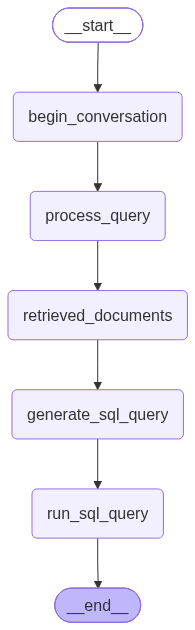

In [26]:
from IPython.display import Image, display

#save png to a file
png_bytes=compiled_workflow.get_graph().draw_mermaid_png()

with open("workflow_graph.png", "wb") as f:
  f.write(png_bytes)

#display the image
display(Image(filename="workflow_graph.png"))

In [ ]:
print(f"Invoking a new test")

db_id="california_schools"
databases_dir = "../../dbs/dev_databases"
db_path = os.path.join(databases_dir, db_id, f"{db_id}.sqlite")

result=compiled_workflow.invoke({
    "query":"What is the highest eligible free rate for K-12 students?",
    "db_id":db_id,
    "db_path":db_path
})

In [ ]:
print(f"Now for the lowest...no need to reconstruct")
result = compiled_workflow.invoke(  #it will not have the conversation from the previous invoke hence need to make it a Statful RAG
    {
        "query": "and the lowest?",
        "db_id": db_id,
        "db_path": db_path
        }
    )

# Making a Stateful RAG

In [22]:
#Import the interrupt function for proper user input handling
from langgraph.types import interrupt

#Add a user input node for conversational flow using Langgraph interrupt
def ask_for_user_input(state: RAGState) -> Dict[str, any]:
  """Ask the user for the next question in the conversation using Langgraph Interrupt"""
  print("\n"+"="*60)
  print("Sql Query executed successfully!")
  print("="*60)

  #show the result
  if state.final_answer:
    print(" RESULT: ")
    print(state.final_answer)

  print("\n"+"-"*60)
  print("What would you like to ask next?")
  print(" (Type 'exit' or 'quit' to end the conversation)")
  print("\n"+"-"*60)

  #use Langgraph interrupt instead of input() -- this works properly in notebooks
  user_input=interrupt("Your question: ")

  if user_input and user_input.strip() in ['quit', 'exit', 'bye', 'done']:
    return {
        "query":"",
        "final_answer":"Goodbye! Thanks for using our system"
    }

  return {
      "query":user_input or "",
      "retrieved_documents":[],   #reset for new query
      "context":"",
      "sql_query":"",
      "reasoning":"",
      "sql_result":{},
      "final_answer":""
  }

In [23]:
#conditional function to decide whether to continue or end
def should_continue(state: RAGState) -> str:
  """Decide to continue the conversation or end it"""
  if state.query == "" or state.query.lower() in ['exit', 'quit', 'bye', 'done']:
    return END

  return "process_query"

In [24]:
#import MemorySaver for checkpointing (required for interrupt functionality)
from langgraph.checkpoint.memory import MemorySaver

#create the conversational workflow graph with proper checkpointing
conversation_workflow=StateGraph(RAGState)

#add nodes
conversation_workflow.add_node("begin_conversation", begin_conversation)
conversation_workflow.add_node("process_query", process_query)
conversation_workflow.add_node("retrieved_documents", retrieved_documents)
conversation_workflow.add_node("generate_sql_query",generate_sql_query)
conversation_workflow.add_node("run_sql_query", run_sql_query)
conversation_workflow.add_node("ask_user_for_input", ask_for_user_input)

#add edges
conversation_workflow.add_edge("begin_conversation", "ask_user_for_input")
#now check if the user quit or inputs a query
conversation_workflow.add_conditional_edges(
    "ask_user_for_input",
    should_continue,
    {
        "process_query":"process_query",
        END:END
    }
)
conversation_workflow.add_edge("process_query","retrieved_documents")
conversation_workflow.add_edge("retrieved_documents","generate_sql_query")
conversation_workflow.add_edge("generate_sql_query","run_sql_query")
conversation_workflow.add_edge("run_sql_query","ask_user_for_input") #looping back and ask the user for more input

#set entry point
conversation_workflow.set_entry_point("begin_conversation")

#Set up MemorySaver for checkpointing (required for interrupt functionality)
memory=MemorySaver()

#compile the workflow with checkpointer
compiled_conversation=conversation_workflow.compile(checkpointer=memory)

print("Conversation workflow compiled successfully")

Conversation workflow compiled successfully


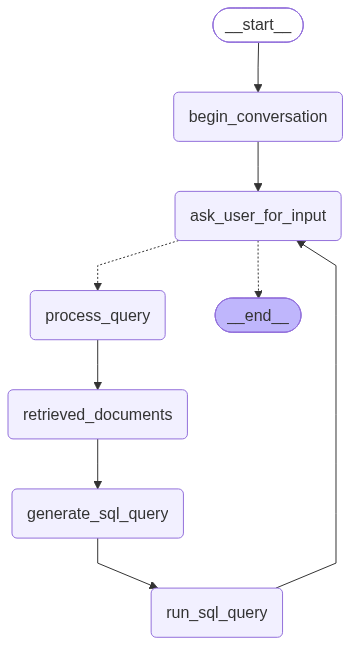

In [30]:
png_bytes=compiled_conversation.get_graph().draw_mermaid_png()

with open("conversation_workflow_graph.png", "wb") as f:
  f.write(png_bytes)

display(Image("conversation_workflow_graph.png"))

In [31]:
from langgraph.types import Command

def chat_with_sql_assistant(db_id: str="formula_1"):
  """
  Start a continuous conversation with the SQL RAG assistant using a while loop.
  This works well in notebooks using Langgraph interrupt functionality.
  """

  print("🚀 Starting SQL RAG Chat Assistant!")
  print(f"📊 Database: {db_id}")
  print("💡 Type 'exit', 'quit', or 'bye' to end the conversation")
  print("=" * 60)

  # Set up database path
  db_path = f"../../dbs/dev_databases/{db_id}/{db_id}.sqlite"

  # Create initial state
  initial_state = {
      "db_id": db_id,
      "db_path": db_path,
      "query": "",
      "retrieved_documents": [],
      "context": "",
      "sql_query": "",
      "reasoning": "",
      "sql_result": {},
      "final_answer": ""
  }

  #create a thread for this conversation
  thread={"configurable": {"thread_id": f"chat_{db_id}"}}

  #initialize the conversation
  conversation_started=False

  while True:
    try:
      if not conversation_started:
        #start the conversation flow
        print(f"\n Assistant: Hello! I'm here to help with your sql queries.")
        print("Ask me about the database, I'll generate a sql query to find the answer")

        conversation_started=True

        #start the workflow and wait for the interrupt
        for event in compiled_conversation.stream(initial_state, thread, stream_mode="updates"):  #stream invokes the compiled workflow but yield data pieces as events as each node returns...invoke return final state after all nodes are completed
          if "__interrupt__" in event:
            break

          #process other events silently for the first run

        # Get user input
        print("\n" + "-" * 40)
        user_input = input("You: ").strip()

        # Check for exit conditions
        if user_input.lower() in ['exit', 'quit', 'bye', 'done', '']:
          print("\n👋 Assistant: Goodbye! Thanks for using the SQL RAG system.")
          break

        print(f"\n🔄 Processing: '{user_input}'")
        print("-" * 40)

        #Continue with the conversation with user input
        for event in compiled_conversation.stream(
            Command(resume=user_input),
            thread,
            stream_mode="Updates"):
          if "__interrupt__" in event:
            #ready for next input
            break
          else:
            # Process events and show results
            for node, data in event.items():
                if node == "run_sql_query" and data and "final_answer" in data:
                    print("\n📊 Assistant: Here's what I found:")
                    print(data["final_answer"].replace("\\\\n", "\n"))
                elif node in ["generate_sql_query"] and data and "sql_query" in data:
                    print(f"\n🔍 SQL Query: {data['sql_query']}")
    except KeyboardInterrupt:
            print("\n\n⚠️ Conversation interrupted by user (Ctrl+C)")
            break
    except Exception as e:
        print(f"\n❌ Error: {e}")
        print("Let's try again...")
        continue

# Start the chat assistant
print("Ready to start chatting! Run the function below:")
print("chat_with_sql_assistant('formula_1')  # or any other database")

Ready to start chatting! Run the function below:
chat_with_sql_assistant('formula_1')  # or any other database


In [32]:
chat_with_sql_assistant("california_schools")

🚀 Starting SQL RAG Chat Assistant!
📊 Database: california_schools
💡 Type 'exit', 'quit', or 'bye' to end the conversation

 Assistant: Hello! I'm here to help with your sql queries.
Ask me about the database, I'll generate a sql query to find the answer

Sql Query executed successfully!

------------------------------------------------------------
What would you like to ask next?
 (Type 'exit' or 'quit' to end the conversation)

------------------------------------------------------------

----------------------------------------
You: What is the highest eligible free rate for K-12 students in the schools in Alameda County?

🔄 Processing: 'What is the highest eligible free rate for K-12 students in the schools in Alameda County?'
----------------------------------------

Sql Query executed successfully!

------------------------------------------------------------
What would you like to ask next?
 (Type 'exit' or 'quit' to end the conversation)

----------------------------------------

KeyboardInterrupt: 

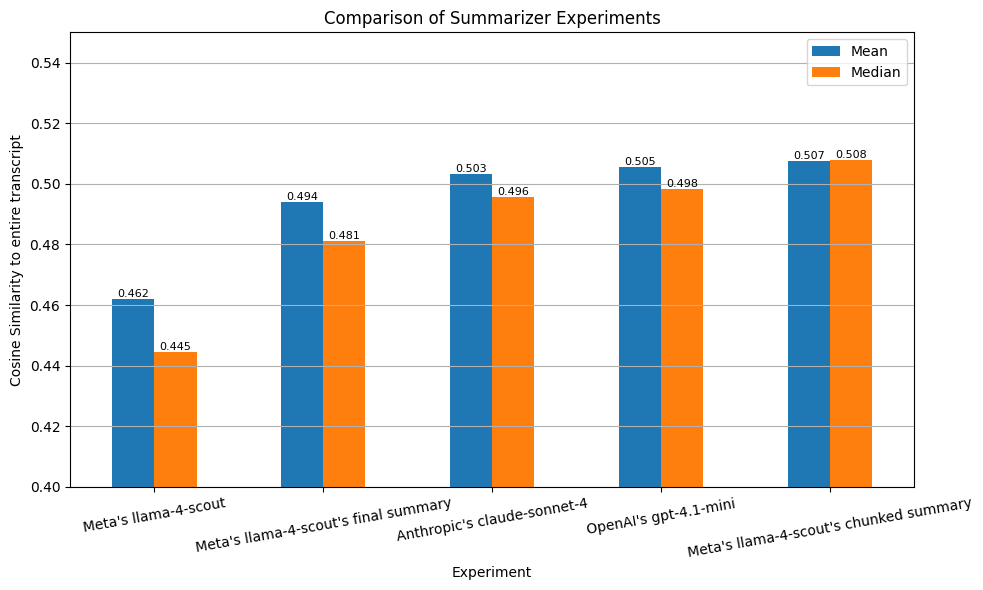

In [33]:
#rando, jsut for summarizer

import matplotlib.pyplot as plt
import pandas as pd

# Raw stats for each experiment
experiments_stats = {
    "Meta's llama-4-scout": {
        "Min": 0.3678571789392403,
        "Max": 0.6836765754435744,
        "Mean": 0.46183578170778994,
        "Median": 0.4445617459123098,
        "Std Dev": 0.07106599558449286
    },
    "Anthropic's claude-sonnet-4": {
        "Min": 0.35896196296172483,
        "Max": 0.6982867425041539,
        "Mean": 0.5030927317982371,
        "Median": 0.49581396432585395,
        "Std Dev": 0.07116457687719842
    },
    "OpenAI's gpt-4.1-mini": {
        "Min": 0.3684184556560857,
        "Max": 0.6892336894358907,
        "Mean": 0.5054158536689127,
        "Median": 0.49833240140267077,
        "Std Dev": 0.0653843868644675
    },
    "Meta's llama-4-scout's chunked summary": {
        "Min": 0.37662817378129276,
        "Max": 0.6869301348924637,
        "Mean": 0.5074499890537177,
        "Median": 0.5077038660215436,
        "Std Dev": 0.06659415576867475
    },
    "Meta's llama-4-scout's final summary": {
        "Min": 0.37285790166864557,
        "Max": 0.681617486689772,
        "Mean": 0.4938881698766774,
        "Median": 0.48126947546342846,
        "Std Dev": 0.0656388961983183
    }
}

# Convert to DataFrame and sort by Median
df = pd.DataFrame(experiments_stats).T
sorted_df = df.sort_values(by="Median", ascending=True)

# Filter to only Mean and Median
mean_median_df = sorted_df[["Mean", "Median"]]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = mean_median_df.plot(kind='bar', ax=ax)
plt.title("Comparison of Summarizer Experiments")
plt.ylabel("Cosine Similarity to entire transcript")
plt.xlabel("Experiment")
plt.xticks(rotation=10)
plt.ylim(0.4, 0.55)
plt.grid(True, axis='y')

# Add value labels
for container in bars.containers:
    bars.bar_label(container, fmt="%.3f", fontsize=8)

plt.tight_layout()
plt.savefig('summary_experiment.png', dpi=500)
plt.show()